# L-FT-$\kappa$ (SVD-clamp) vs standard L-N (regular NODE) — partial-obs Duffing, 10 seeds

Head-to-head comparison of the **best** model from the 3-variant study
(`duffing_kappa_bounded_youla_skew_3variant_10seed.ipynb`) — the $\kappa$-bounded split operator
**`L-FT-$\kappa$ (SVD-clamp)`**, kept **exactly as implemented there** — against a standard
**unstructured latent NODE** **`L-N`** ($F(z,u)=\mathrm{MLP}([z,u])$, no split structure), over
10 seeds on the same partial-observation Duffing latent task.

Both models share the bounded encoder, linear decoder, fixed-step **rk4** rollout, trainer, and data
(fixed across seeds; only the init varies); only the latent dynamics differ. The full diagnostic suite
of the source notebook is reused:
- **head-to-head over both models**: training curves, best-val distribution, divergence headline,
  reconstruction, per-horizon MSE, recovery of $q,\dot q$, phase portrait, latent PCA, forward-invariance $\lVert z\rVert$.
- **structured-model checks over the SVD-clamp** (L-N has no $A(z)$/$g$): $\kappa(A)$ table/histogram,
  cond(A) panel, $\lVert K\rVert_2/\kappa(K)$, $A(z)$-spectrum, decoded equilibrium map.
- **L-N analog**: the spectrum panel also shows the L-N field-Jacobian eigenvalues $\mathrm{eig}(\partial F/\partial z)$.

> Delivered unexecuted; run the full 10-seed sweep locally. rk4 is used deliberately.

In [1]:
from __future__ import annotations
import time, pathlib, math, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fnn
import matplotlib.pyplot as plt

torch.set_num_threads(max(1, (os.cpu_count() or 2) // 2))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# ------------------------------- CONFIG -----------------------------------
SEEDS         = list(range(10))  # 10 seeds (seed 2 is the historically hard one)
N_EPOCHS      = 200
LAM_RES       = 1e-2             # residual-reg weight, identical across variants (accuracy/recovery sweet spot)
KAPPA_MAX     = 25.0            # hard cap on cond(A)=sigma_max(A)/lambda_min(-sym A) for the bounded variants
SKEW_FRAC     = 0.6            # fraction of the (kappa_max-1) budget given to the skew part
SIGMA_MIN     = 0.1
R_G           = 2.0          # g-image box radius: equilibria confined to [-R_g, R_g]^m
Z_SCALE       = 2.0         # bounded-encoder output scale
M_LAT         = 4          # latent dim (even -> kappa(skew) well defined)
LR, BATCH, CLIP = 3e-3, 64, 1.0

r_in = R_G * math.sqrt(M_LAT)   # radius of ball enclosing the g-image box; certified R = kappa * r_in
print(f'kappa_max={KAPPA_MAX}  skew_frac={SKEW_FRAC}  lam_res={LAM_RES}  seeds={SEEDS}  epochs={N_EPOCHS}')
print(f'r_in = R_g*sqrt(m) = {r_in:.3f}   ->   certified R = kappa_max*r_in = {KAPPA_MAX*r_in:.1f}')

device: cpu
kappa_max=25.0  skew_frac=0.6  lam_res=0.01  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  epochs=200
r_in = R_g*sqrt(m) = 4.000   ->   certified R = kappa_max*r_in = 100.0


## Duffing plant (verbatim)

In [2]:
from dataclasses import dataclass

@dataclass(frozen=True)
class DuffingParams:
    delta: float = 0.2

def F(x, u, params):
    x1 = x[..., 0]; x2 = x[..., 1]
    return np.stack([x2, -params.delta * x2 - x1**3 + x1 + np.asarray(u)], axis=-1)

def equilibria(u):
    roots = np.roots([1.0, 0.0, -1.0, -float(u)])
    real = sorted(r.real for r in roots if abs(r.imag) < 1e-9)
    return [np.array([r, 0.0]) for r in real]

def sinks(u):
    eqs = equilibria(u)
    return {"left": eqs[0], "right": eqs[2]} if len(eqs) == 3 else {"only": eqs[0]}

def simulate(x0, u_of_t, params, t_grid):
    xs = np.empty((len(t_grid), 2)); xs[0] = x0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]; h = t_grid[i+1] - t; x = xs[i]
        u1 = u_of_t(t); u2 = u_of_t(t + 0.5*h); u4 = u_of_t(t + h)
        k1 = F(x, u1, params); k2 = F(x + 0.5*h*k1, u2, params)
        k3 = F(x + 0.5*h*k2, u2, params); k4 = F(x + h*k3, u4, params)
        xs[i+1] = x + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return xs

params = DuffingParams(delta=0.2)
print('open-loop sinks at u=0:', sinks(0.0))

open-loop sinks at u=0: {'left': array([-1.,  0.]), 'right': array([1., 0.])}


## Data (verbatim pipeline)

In [3]:
h_dt   = 0.05
tau    = 8
L      = 200
L_eval = 600
u_range = 0.25
x_range = 1.6
R_LATENT = R_G          # latent box radius used by the diagnostics

def make_dataset(n_traj=512, L=L, tau=tau, h=h_dt, seed=0):
    rng = np.random.default_rng(seed)
    Ttot = tau + L + 1
    t_grid = np.arange(Ttot) * h
    Xfull = np.zeros((n_traj, Ttot, 2), dtype=np.float32)
    U = np.zeros((n_traj,), dtype=np.float32)
    for i in range(n_traj):
        x0 = np.array([rng.uniform(-x_range, x_range), rng.uniform(-1.0, 1.0)])
        u = float(rng.uniform(-u_range, u_range))
        Xfull[i] = simulate(x0, lambda t, _u=u: _u, params, t_grid).astype(np.float32)
        U[i] = u
    Y = Xfull[..., 0]
    return (torch.from_numpy(Y[:, :tau]), torch.from_numpy(U),
            torch.from_numpy(Y[:, tau:tau+L+1]), torch.from_numpy(Xfull[:, tau:tau+L+1]))

Wtr, Utr, Ytr, Xtr = make_dataset(n_traj=512, L=L,      seed=0)
Wva, Uva, Yva, Xva = make_dataset(n_traj=64,  L=L_eval, seed=1)
Wtr_d, Utr_d, Ytr_d = Wtr.to(device), Utr.to(device), Ytr.to(device)
Wva_d, Uva_d, Yva_d = Wva.to(device), Uva.to(device), Yva.to(device)
print('train window', Wtr.shape, '| val window', Wva.shape, '| eval horizon', L_eval)

train window torch.Size([512, 8]) | val window torch.Size([64, 8]) | eval horizon 600


## Models — shared encoder/decoder; L-N (unstructured) vs L-FT-$\kappa$ (SVD-clamp)

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, depth=3, last_zero=False):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)
        if last_zero:
            with torch.no_grad():
                self.net[-1].weight.zero_(); self.net[-1].bias.zero_()
    def forward(self, z): return self.net(z)

class Encoder(nn.Module):
    def __init__(self, tau, m, hidden=64, depth=2, z_scale=Z_SCALE):
        super().__init__(); self.net = MLP(tau, m, hidden, depth); self.z_scale = z_scale
    def forward(self, w): return self.z_scale * torch.tanh(self.net(w))

class LinearDecoder(nn.Module):
    def __init__(self, m): super().__init__(); self.c = nn.Linear(m, 1, bias=True)
    def forward(self, z): return self.c(z).squeeze(-1)

class LatentSysID(nn.Module):
    def __init__(self, encoder, dynamics, decoder):
        super().__init__(); self.encoder = encoder; self.dynamics = dynamics; self.decoder = decoder
    def encode(self, w): return self.encoder(w)
    def decode(self, z): return self.decoder(z)
    def F(self, z, u):  return self.dynamics.F(z, u)

class LatentFTNODEBase(nn.Module):
    '''Shared g(z,u)=R_g*tanh(MLP) and F(z,u)=A(z)(z-g); subclasses implement A(z).'''
    def __init__(self, m=M_LAT, q=1, hidden=64, depth=3, sigma_min=SIGMA_MIN, R_g=R_G):
        super().__init__()
        self.m, self.q, self.sigma_min, self.R_g = m, q, sigma_min, R_g
        self.g_net = MLP(m + q, m, hidden, depth, last_zero=True)
        self.register_buffer('_eye', torch.eye(m))
    def g(self, z, u):
        if u.dim() == z.dim() - 1: u = u.unsqueeze(-1)
        return self.R_g * torch.tanh(self.g_net(torch.cat([z, u], -1)))
    def A(self, z):
        raise NotImplementedError
    def F(self, z, u):
        return torch.einsum('bij,bj->bi', self.A(z), z - self.g(z, u))

### Variant 1 — L-N (regular / unstructured latent NODE)
$F(z,u)=\mathrm{MLP}([z,u])$ — no split structure (no $A(z)$, no $g$). The field-MLP width is set so its
parameter count **matches the SVD-clamp dynamics** ($\approx$ 28.3k; hidden=95, depth=4).

In [5]:
class LatentNODE(nn.Module):
    '''Standard latent NODE: F(z,u) = MLP([z,u]); no structural prior. hidden=95 makes its dynamics
    param count (~28.3k) match the SVD-clamp. Has no .A and no .g, so the residual reg is inert and the
    FT/kappa diagnostics skip it.'''
    def __init__(self, m=M_LAT, q=1, hidden=95, depth=4):
        super().__init__()
        self.m = m; self.q = q
        self.f_net = MLP(m + q, m, hidden=hidden, depth=depth)
    def F(self, z, u):
        if u.dim() == z.dim() - 1: u = u.unsqueeze(-1)
        return self.f_net(torch.cat([z, u], dim=-1))

### Variant 2 — L-FT-$\kappa$ (SVD-clamp): reference mitigation [1]

In [6]:
def spectral_clamp(Bmat, cap):
    '''Scale each (m x m) matrix so its spectral norm <= cap (batched SVD; [1]).
    NOTE: matrix_norm(ord=2) is degenerate on skew inputs (singular values are doubled),
    so its backward is ill-conditioned -- exactly what the Youla variant avoids.'''
    s = torch.linalg.matrix_norm(Bmat, ord=2)
    return Bmat * torch.clamp(cap / (s + 1e-12), max=1.0).view(-1, 1, 1)

class LatentFTNODEClamp(LatentFTNODEBase):
    '''[1]: A = -(sigma_min I + P) + K, ||P||_2<=c_P, ||K||_2<=c_K via spectral_clamp.
    => cond(A) <= (sigma_min + c_P + c_K)/sigma_min = kappa_max.'''
    def __init__(self, c_P, c_K, **kw):
        super().__init__(**kw)
        self.c_P, self.c_K = float(c_P), float(c_K)
        m = self.m
        self.L_net = MLP(m, m*m, 64, 3)
        self.S_net = MLP(m, m*m, 64, 3, last_zero=True)
    def A(self, z):
        Lc = spectral_clamp(self.L_net(z).view(-1, self.m, self.m), self.c_P ** 0.5)
        P = Lc @ Lc.transpose(1, 2)
        Mr = self.S_net(z).view(-1, self.m, self.m)
        K = spectral_clamp(Mr - Mr.transpose(1, 2), self.c_K)
        return -(self.sigma_min * self._eye + P) + K

### Budget, builders, and init-time $\kappa$ sanity

In [7]:
# --- kappa budget split for the SVD-clamp (kept exactly as in the source notebook) ---
budget = SIGMA_MIN * (KAPPA_MAX - 1.0)          # = c_P + c_K
c_K    = SKEW_FRAC * budget                      # skew spectral budget ||K||_2 <= c_K
c_P    = (1.0 - SKEW_FRAC) * budget              # sym spread budget  ||P||_2 <= c_P
print(f'budget={budget:.3f}  c_P={c_P:.3f}  c_K={c_K:.3f}')

def build_ln():    return LatentSysID(Encoder(tau, M_LAT), LatentNODE(m=M_LAT, hidden=95, depth=4), LinearDecoder(M_LAT))
def build_clamp(): return LatentSysID(Encoder(tau, M_LAT), LatentFTNODEClamp(c_P=c_P, c_K=c_K),       LinearDecoder(M_LAT))

MODEL_CONFIGS = [
    {'name': 'L-N',                'kind': 'ln', 'build': build_ln,    'lam_res': 0.0,     'color': 'C3', 'bounded': False},
    {'name': 'L-FT-k (SVD-clamp)', 'kind': 'ft', 'build': build_clamp, 'lam_res': LAM_RES, 'color': 'C0', 'bounded': True},
]
MODEL_NAMES = [c['name'] for c in MODEL_CONFIGS]
MODEL_COLOR = {c['name']: c['color'] for c in MODEL_CONFIGS}
FT_NAMES    = [c['name'] for c in MODEL_CONFIGS if c['kind'] == 'ft']   # structured models: just the SVD-clamp
def slug(name): return name.replace('+', '-').replace(' ', '-').replace('(', '').replace(')', '').lower()

# --- kappa / spectral helpers (used by the FT-only diagnostics) ---
@torch.no_grad()
def A_stats(dyn, Z):
    A = dyn.A(Z).cpu().numpy()
    sv = np.linalg.svd(A, compute_uv=False)
    lmin = -np.linalg.eigvalsh((A + A.transpose(0, 2, 1)) / 2)[:, -1]
    maxre = np.linalg.eigvals(A).real.max(1)
    return maxre, sv[:, 0], sv[:, 0] / np.maximum(lmin, 1e-12)

@torch.no_grad()
def skew_stats(dyn, Z):
    A = dyn.A(Z); Ksk = 0.5 * (A - A.transpose(-1, -2))
    sv = torch.linalg.svdvals(Ksk).cpu().numpy()
    return sv[:, 0], sv[:, 0] / np.maximum(sv[:, -1], 1e-12)

# --- init-time kappa sanity over the latent box (FT models only) ---
torch.manual_seed(0)
Zbox0 = ((2 * torch.rand(4000, M_LAT) - 1) * Z_SCALE).to(device)
print(f'\n{"variant":20s} {"kappa med":10s} {"kappa max":10s} {"||K||2 max":11s} {"cert R max":10s}')
for cfg in MODEL_CONFIGS:
    if cfg['kind'] != 'ft':
        print(f'{cfg["name"]:20s} (unstructured NODE - no A(z))'); continue
    dyn = cfg['build']().dynamics.eval()
    _, _, kap = A_stats(dyn, Zbox0); knorm, _ = skew_stats(dyn, Zbox0)
    print(f'{cfg["name"]:20s} {np.median(kap):<10.2f} {kap.max():<10.2f} {knorm.max():<11.3f} {kap.max()*r_in:<10.1f}')
print(f'\nSVD-clamp targets: kappa <= kappa_max = {KAPPA_MAX},  ||K||_2 <= c_K = {c_K:.3f}')

budget=2.400  c_P=0.960  c_K=1.440

variant              kappa med  kappa max  ||K||2 max  cert R max
L-N                  (unstructured NODE - no A(z))
L-FT-k (SVD-clamp)   1.45       1.72       0.000       6.9       

SVD-clamp targets: kappa <= kappa_max = 25.0,  ||K||_2 <= c_K = 1.440


## rk4 rollout + trainer (verbatim)

In [8]:
def rk4_step(F_fn, z, u, h):
    k1 = F_fn(z, u); k2 = F_fn(z + 0.5*h*k1, u)
    k3 = F_fn(z + 0.5*h*k2, u); k4 = F_fn(z + h*k3, u)
    return z + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def rollout_y(model, window, u, L, h):
    z = model.encode(window); ys = [model.decode(z)]; zs = [z]
    for _ in range(L):
        z = rk4_step(model.F, z, u, h); zs.append(z); ys.append(model.decode(z))
    return torch.stack(ys, 1), torch.stack(zs, 1)

def train_one(model, n_epochs=N_EPOCHS, lr=LR, batch=BATCH, clip=CLIP, label='model',
              ckpt_path=None, lam_res=0.0, verbose=True):
    model = model.to(device)
    if ckpt_path is None: ckpt_path = f'best-{label}.pth'
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    hist = {'train': [], 'val_extrap': [], 'zmax': [], 'res': [], 'diverged_at': None,
            'best_val': float('inf'), 'best_epoch': None, 'ckpt_path': ckpt_path}
    diverged = False; t0 = time.time()
    for epoch in range(n_epochs):
        model.train(); perm = torch.randperm(Wtr_d.shape[0], device=device)
        ep_losses, ep_res, ep_zmax = [], [], 0.0
        for i in range(0, len(perm), batch):
            idx = perm[i:i+batch]; w = Wtr_d[idx]; u = Utr_d[idx]; y = Ytr_d[idx]
            yhat, zs = rollout_y(model, w, u, L, h_dt)
            loss = ((yhat - y) ** 2).mean()
            res_pen = zs.new_zeros(())
            if lam_res > 0.0 and hasattr(model.dynamics, 'g'):
                u_steps = u.unsqueeze(1).expand(zs.shape[0], zs.shape[1])
                res_pen = ((zs - model.dynamics.g(zs, u_steps)) ** 2).sum(-1).mean()
                loss = loss + lam_res * res_pen
            if not torch.isfinite(loss):
                diverged = True; hist['diverged_at'] = epoch; break
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip); opt.step()
            ep_losses.append(loss.item()); ep_res.append(res_pen.item())
            with torch.no_grad(): ep_zmax = max(ep_zmax, zs.norm(dim=-1).max().item())
        if diverged:
            if verbose: print(f'[{label}] diverged at epoch {epoch}')
            break
        sched.step(); model.eval()
        with torch.no_grad():
            yhat_v, _ = rollout_y(model, Wva_d, Uva_d, L_eval, h_dt)
            val = ((yhat_v - Yva_d) ** 2).mean().item()
        hist['train'].append(float(np.mean(ep_losses))); hist['val_extrap'].append(val)
        hist['zmax'].append(ep_zmax); hist['res'].append(float(np.mean(ep_res)) if ep_res else 0.0)
        if np.isfinite(val) and val < hist['best_val']:
            hist['best_val'] = val; hist['best_epoch'] = epoch
            torch.save(model.state_dict(), ckpt_path)
        if verbose and (epoch % 20 == 0 or epoch == n_epochs - 1):
            print(f'[{label}] ep {epoch:3d}  train {hist["train"][-1]:.3e}  val {val:.3e}  '
                  f'res {hist["res"][-1]:.3e}  zmax {ep_zmax:.2f}  ({time.time()-t0:.0f}s)')
    if verbose and hist['best_epoch'] is not None:
        print(f'[{label}] best val {hist["best_val"]:.3e} @ ep {hist["best_epoch"]}')
    return model, hist

def restore_best(model, hist, label='', verbose=True):
    cp = hist.get('ckpt_path')
    if hist.get('best_epoch') is not None and cp and pathlib.Path(cp).exists():
        model.load_state_dict(torch.load(cp, map_location=device))
    model.eval(); return model

## Run all variants $\times$ seeds

In [9]:
histories = {name: [] for name in MODEL_NAMES}
models    = {name: [] for name in MODEL_NAMES}
t_all = time.time()
for cfg in MODEL_CONFIGS:
    name = cfg['name']
    for seed in SEEDS:
        torch.manual_seed(seed); np.random.seed(seed)
        model = cfg['build']()
        ckpt = f'best-duffing-svdclamp-vs-ln-{slug(name)}-seed{seed}.pth'
        t0 = time.time()
        model, hist = train_one(model, n_epochs=N_EPOCHS, lr=LR, batch=BATCH, clip=CLIP,
                                label=f'{name}-s{seed}', ckpt_path=ckpt, lam_res=cfg['lam_res'], verbose=False)
        restore_best(model, hist, f'{name}-s{seed}', verbose=False)
        histories[name].append(hist); models[name].append(model)
        print(f'[{name:20s} seed {seed}] best_val {hist["best_val"]:.3e} @ ep {hist["best_epoch"]}  '
              f'diverged={hist["diverged_at"]}  ({time.time()-t0:.0f}s)')
print(f'total training time: {time.time()-t_all:.0f}s')

[L-N                  seed 0] best_val 9.221e-03 @ ep 176  diverged=None  (517s)
[L-N                  seed 1] best_val 2.102e-01 @ ep 80  diverged=None  (506s)
[L-N                  seed 2] best_val 1.983e-01 @ ep 65  diverged=None  (507s)
[L-N                  seed 3] best_val 8.282e-03 @ ep 183  diverged=None  (505s)
[L-N                  seed 4] best_val 5.785e-02 @ ep 142  diverged=None  (503s)
[L-N                  seed 5] best_val 1.977e-01 @ ep 70  diverged=None  (505s)
[L-N                  seed 6] best_val 1.368e-01 @ ep 85  diverged=None  (505s)
[L-N                  seed 7] best_val 6.126e-02 @ ep 183  diverged=None  (503s)
[L-N                  seed 8] best_val 1.799e-02 @ ep 136  diverged=None  (508s)
[L-N                  seed 9] best_val 4.741e-02 @ ep 186  diverged=None  (505s)
[L-FT-k (SVD-clamp)   seed 0] best_val 5.970e-03 @ ep 178  diverged=None  (1953s)
[L-FT-k (SVD-clamp)   seed 1] best_val 8.250e-03 @ ep 182  diverged=None  (1953s)
[L-FT-k (SVD-clamp)   seed 2] 

## Diagnostics — aggregation helpers

In [10]:
def stack_key(name, key, n=None):
    if n is None: n = N_EPOCHS
    hs = histories[name]; arr = np.full((len(hs), n), np.nan)
    for i, h in enumerate(hs):
        v = np.asarray(h[key], dtype=float); k = min(len(v), n); arr[i, :k] = v[:k]
    return arr

def band(ax, arr, color, label, logy=False):
    x = np.arange(arr.shape[1]); mean = np.nanmean(arr, axis=0); std = np.nanstd(arr, axis=0)
    lo = mean - std; hi = mean + std
    if logy:
        lo = np.maximum(lo, 1e-12); mean = np.maximum(mean, 1e-12)
        ax.semilogy(x, mean, color=color, lw=1.5, label=label)
    else:
        ax.plot(x, mean, color=color, lw=1.5, label=label)
    ax.fill_between(x, lo, hi, color=color, alpha=0.18)

def seed_grid(n, ncols=5, panel=(2.7, 2.4), sharex=False, sharey=False):
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel[0]*ncols, panel[1]*nrows),
                             squeeze=False, sharex=sharex, sharey=sharey)
    axes = axes.ravel()
    for j in range(n, len(axes)): axes[j].axis('off')
    return fig, axes

## Precompute held-out rollouts (shared by later diagnostics)

In [11]:
ROLL = {}
for name in MODEL_NAMES:
    yh = np.full((len(SEEDS), Wva_d.shape[0], L_eval + 1), np.nan, dtype=np.float32)
    zz = torch.full((len(SEEDS), Wva_d.shape[0], L_eval + 1, M_LAT), float('nan'))
    for si in range(len(SEEDS)):
        with torch.no_grad():
            yhat, zs = rollout_y(models[name][si], Wva_d, Uva_d, L_eval, h_dt)
        yh[si] = np.where(np.isfinite(yhat.cpu().numpy()), yhat.cpu().numpy(), np.nan); zz[si] = zs.cpu()
    ROLL[name] = {'yhat': yh, 'z': zz}
Yva_np  = Yva.numpy(); tline_e = np.arange(L_eval + 1) * h_dt; T_train = L * h_dt
print('precomputed val rollouts for', list(ROLL.keys()))

precomputed val rollouts for ['L-N', 'L-FT-k (SVD-clamp)']


### D1 + K1. Training curves (mean $\pm$ std across seeds) and divergence headline
The divergence count is the headline: the unbounded baseline should lose seed(s) (incl. seed 2), the
bounded variants should keep all of them.

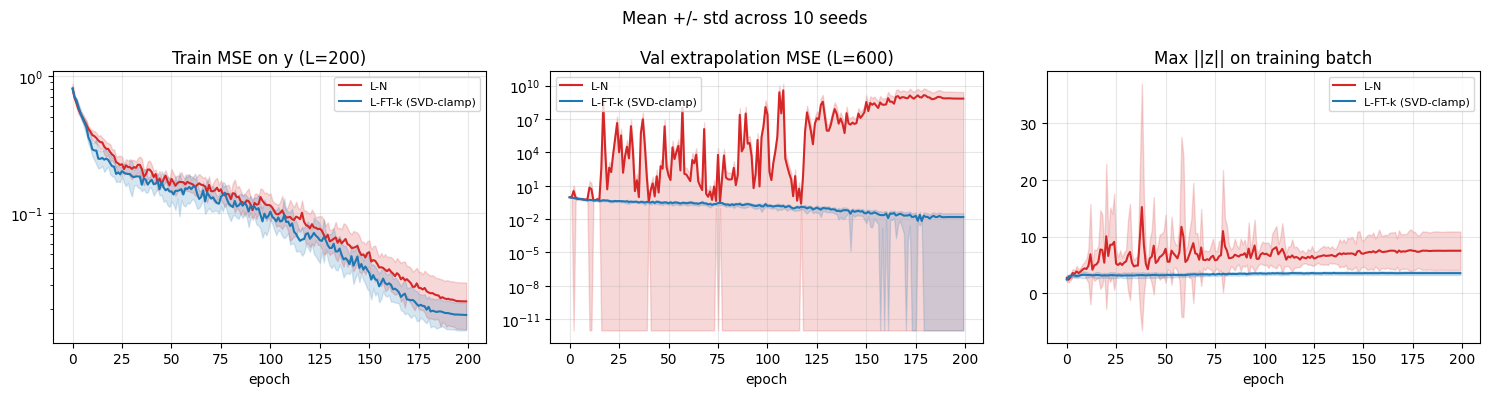

Divergence + best-val summary:
  L-N                 : diverged 0/10                 best-val median 5.956e-02  mean 9.450e-02
  L-FT-k (SVD-clamp)  : diverged 0/10                 best-val median 5.648e-03  mean 5.998e-03


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name in MODEL_NAMES:
    c = MODEL_COLOR[name]
    band(axes[0], stack_key(name, 'train'),      c, name, logy=True)
    band(axes[1], stack_key(name, 'val_extrap'), c, name, logy=True)
    band(axes[2], stack_key(name, 'zmax'),       c, name, logy=False)
axes[0].set_title(f'Train MSE on y (L={L})'); axes[1].set_title(f'Val extrapolation MSE (L={L_eval})')
axes[2].set_title('Max ||z|| on training batch')
for ax in axes: ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle(f'Mean +/- std across {len(SEEDS)} seeds'); plt.tight_layout(); plt.show()

print('Divergence + best-val summary:')
for name in MODEL_NAMES:
    nd = sum(h['diverged_at'] is not None for h in histories[name])
    bv = np.array([h['best_val'] for h in histories[name]], float); fin = bv[np.isfinite(bv)]
    ds = [s for s, h in zip(SEEDS, histories[name]) if h['diverged_at'] is not None]
    print(f'  {name:20s}: diverged {nd}/{len(SEEDS)} {("seeds "+str(ds)) if ds else "":14s}  '
          f'best-val median {np.median(fin) if fin.size else float("nan"):.3e}  '
          f'mean {fin.mean() if fin.size else float("nan"):.3e}')

### K5. Forward invariance: max $\lVert z\rVert$ vs $r_{\mathrm{in}}$ and certified $R$
Every seed's rollout latent norm; the bounded variants must stay under the certified
$R=\kappa_{\max}r_{\mathrm{in}}$, the unbounded one may run away.

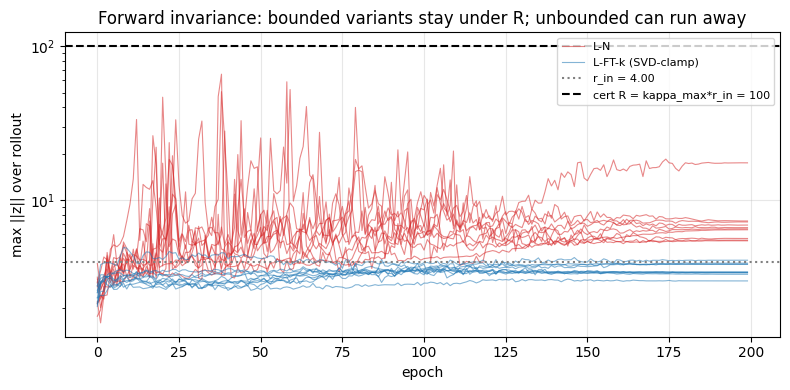

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in MODEL_NAMES:
    c = MODEL_COLOR[name]
    for si, h in enumerate(histories[name]):
        if h['zmax']:
            ax.plot(h['zmax'], color=c, lw=0.8, alpha=0.55, label=name if si == 0 else None)
ax.axhline(r_in, ls=':', c='gray', label=f'r_in = {r_in:.2f}')
ax.axhline(KAPPA_MAX * r_in, ls='--', c='k', label=f'cert R = kappa_max*r_in = {KAPPA_MAX*r_in:.0f}')
ax.set_yscale('log'); ax.set_xlabel('epoch'); ax.set_ylabel('max ||z|| over rollout')
ax.set_title('Forward invariance: bounded variants stay under R; unbounded can run away')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### D2. Best-val MSE distribution (headline consistency metric)

/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_2652/3737889254.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=MODEL_NAMES, showfliers=False, widths=0.5)


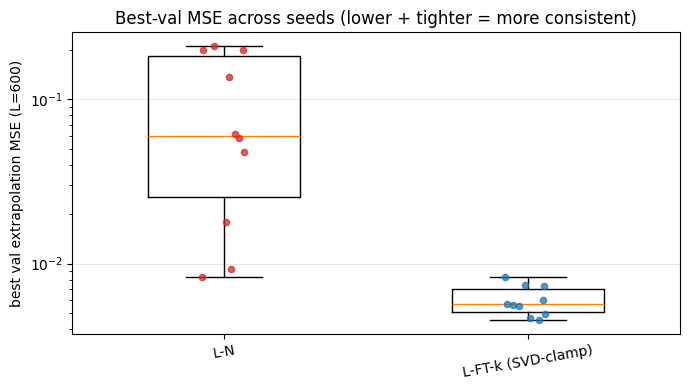

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
data = [np.array([h['best_val'] for h in histories[name]], float) for name in MODEL_NAMES]
data = [d[np.isfinite(d)] for d in data]
ax.boxplot(data, labels=MODEL_NAMES, showfliers=False, widths=0.5)
rng = np.random.default_rng(0)
for i, (name, d) in enumerate(zip(MODEL_NAMES, data), start=1):
    x = i + (rng.random(len(d)) - 0.5) * 0.15
    ax.scatter(x, d, s=20, color=MODEL_COLOR[name], alpha=0.75, zorder=3)
ax.set_yscale('log'); ax.set_ylabel(f'best val extrapolation MSE (L={L_eval})')
ax.set_title('Best-val MSE across seeds (lower + tighter = more consistent)')
ax.grid(alpha=0.3, axis='y'); plt.xticks(rotation=10); plt.tight_layout(); plt.show()

### K2 + K3. $\kappa(A)$ verification and histogram over box $\cup$ rollout
The bounded variants must satisfy $\kappa(A)\le\kappa_{\max}$ everywhere (by construction); the
unbounded one has a long tail that inflates the certified $R$.

variant              maxRe(A)  smax med  kappa med  kappa max  cert R  
L-FT-k (SVD-clamp)   -0.100    1.679     15.97      20.29      81.2    

cap: kappa <= 25.0 for the bounded variants (by construction)


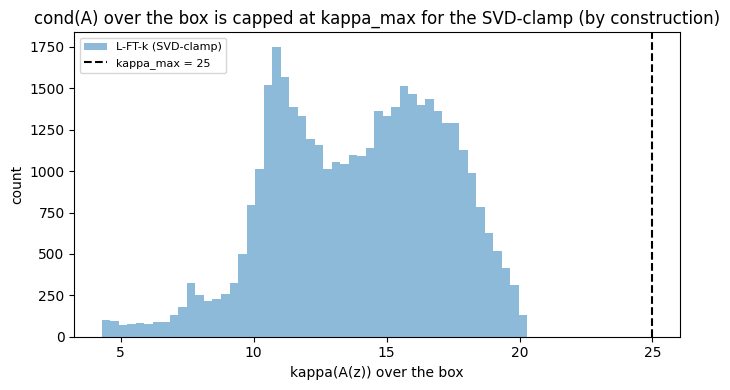

In [15]:
gbox = torch.Generator().manual_seed(0)
Zbox = ((2 * torch.rand(4000, M_LAT, generator=gbox) - 1) * Z_SCALE).to(device)
kap_hist = {}
print(f'{"variant":20s} {"maxRe(A)":9s} {"smax med":9s} {"kappa med":10s} {"kappa max":10s} {"cert R":8s}')
for name in FT_NAMES:
    mr_all, sm_all, km_all, kb_all = [], [], [], []
    for si, m in enumerate(models[name]):
        dyn = m.dynamics.eval()
        Zvis = ROLL[name]['z'][si].reshape(-1, M_LAT); Zvis = Zvis[torch.isfinite(Zvis).all(1)]
        if Zvis.shape[0] > 4000: Zvis = Zvis[torch.randperm(Zvis.shape[0])[:4000]]
        Zall = torch.cat([Zbox.cpu(), Zvis], 0).to(device)
        mr, sm, kap = A_stats(dyn, Zall); mr_all.append(mr.max()); sm_all.append(sm); km_all.append(kap)
        _, _, kb = A_stats(dyn, Zbox); kb_all.append(kb)
    sm_cat = np.concatenate(sm_all); kap_cat = np.concatenate(km_all); kap_hist[name] = np.concatenate(kb_all)
    print(f'{name:20s} {max(mr_all):<+9.3f} {np.median(sm_cat):<9.3f} {np.median(kap_cat):<10.2f} '
          f'{kap_cat.max():<10.2f} {kap_cat.max()*r_in:<8.1f}')
print(f'\ncap: kappa <= {KAPPA_MAX} for the bounded variants (by construction)')

fig, ax = plt.subplots(figsize=(7, 4))
for name in FT_NAMES:
    ax.hist(kap_hist[name], bins=50, alpha=0.5, label=name, color=MODEL_COLOR[name])
ax.axvline(KAPPA_MAX, ls='--', c='k', label=f'kappa_max = {KAPPA_MAX:.0f}')
ax.set_xlabel('kappa(A(z)) over the box'); ax.set_ylabel('count')
ax.set_title('cond(A) over the box is capped at kappa_max for the SVD-clamp (by construction)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

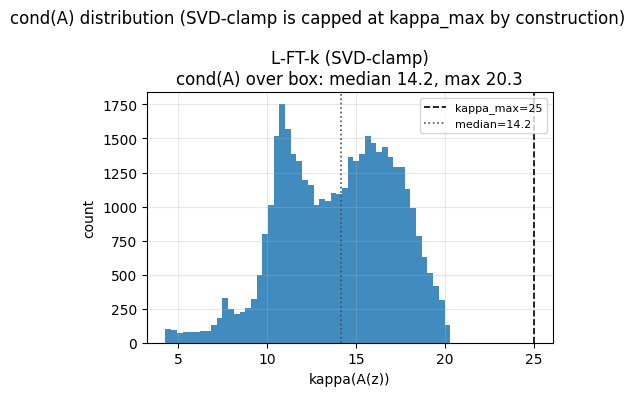

In [16]:
# per-variant cond(A) panel (FT models only; reuses kap_hist from the cell above, no recompute).
n = len(FT_NAMES)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False); axes = axes.ravel()
for ax, name in zip(axes, FT_NAMES):
    k = np.asarray(kap_hist[name], float)
    ax.hist(k, bins=50, color=MODEL_COLOR[name], alpha=0.85)
    ax.axvline(KAPPA_MAX, ls='--', c='k', lw=1.2, label=f'kappa_max={KAPPA_MAX:.0f}')
    ax.axvline(np.median(k), ls=':', c='0.3', lw=1.2, label=f'median={np.median(k):.1f}')
    ax.set_title(f'{name}\ncond(A) over box: median {np.median(k):.1f}, max {k.max():.1f}')
    ax.set_xlabel('kappa(A(z))'); ax.set_ylabel('count'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('cond(A) distribution (SVD-clamp is capped at kappa_max by construction)')
plt.tight_layout(); plt.show()

### K4. Skew-part diagnostics: $\lVert K\rVert_2=\beta_{\max}$ and $\kappa(K)=\beta_{\max}/\beta_{\min}$
Extracted as the skew part $\tfrac12(A-A^\top)$ of the SVD-clamp $A(z)$. The clamp keeps $\lVert K\rVert_2\le c_K$ by projection; $\kappa(K)$ is left uncontrolled (the skew can be near-singular).

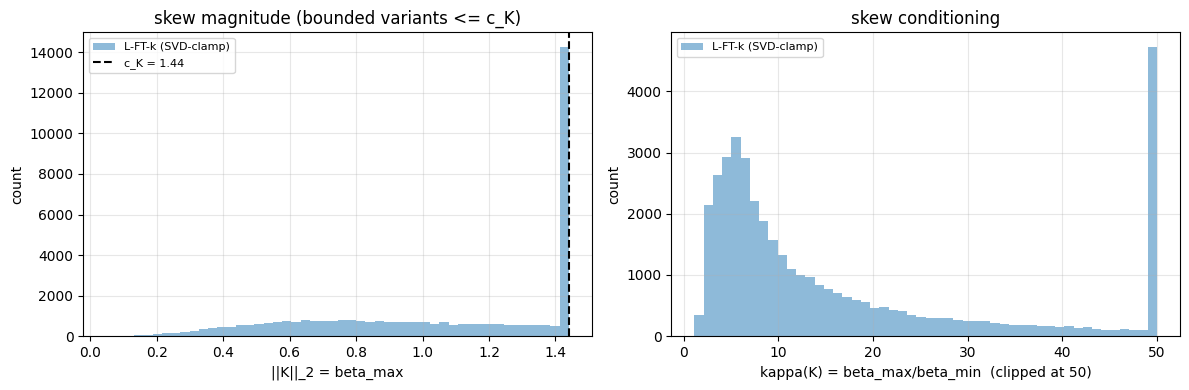

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in FT_NAMES:
    kn_all, kc_all = [], []
    for m in models[name]:
        kn, kc = skew_stats(m.dynamics.eval(), Zbox); kn_all.append(kn); kc_all.append(kc)
    axes[0].hist(np.concatenate(kn_all), bins=50, alpha=0.5, label=name, color=MODEL_COLOR[name])
    kc = np.concatenate(kc_all); kc = kc[np.isfinite(kc)]
    axes[1].hist(np.clip(kc, 0, 50), bins=50, alpha=0.5, label=name, color=MODEL_COLOR[name])
axes[0].axvline(c_K, ls='--', c='k', label=f'c_K = {c_K:.2f}')
axes[0].set_xlabel('||K||_2 = beta_max'); axes[0].set_title('skew magnitude (bounded variants <= c_K)')
axes[1].set_xlabel('kappa(K) = beta_max/beta_min  (clipped at 50)'); axes[1].set_title('skew conditioning')
for a in axes: a.set_ylabel('count'); a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### D3. Per-seed reconstruction grid (one held-out trajectory)

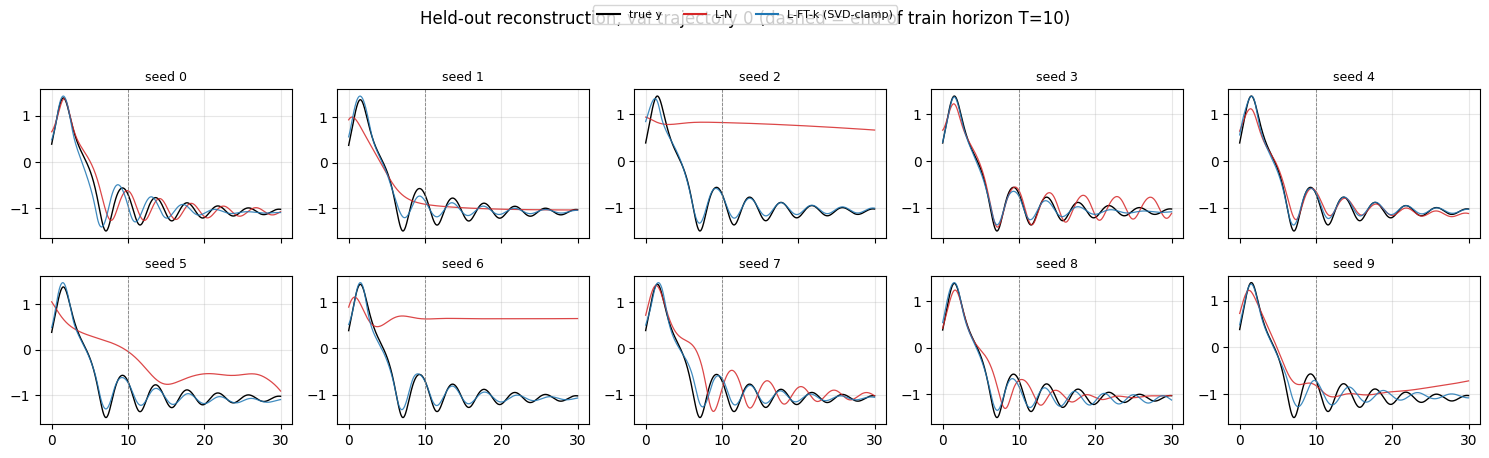

In [18]:
TRAJ = 0
fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(3.0, 2.2), sharex=True)
for si, seed in enumerate(SEEDS):
    ax = axes[si]; ax.plot(tline_e, Yva_np[TRAJ], 'k', lw=1.0)
    for name in MODEL_NAMES:
        yhat = ROLL[name]['yhat'][si, TRAJ]
        if np.all(np.isfinite(yhat)): ax.plot(tline_e, yhat, color=MODEL_COLOR[name], lw=0.9, alpha=0.85)
    ax.axvline(T_train, color='gray', lw=0.6, ls='--'); ax.set_title(f'seed {seed}', fontsize=9); ax.grid(alpha=0.3)
handles = [plt.Line2D([], [], color='k', label='true y')] + \
          [plt.Line2D([], [], color=MODEL_COLOR[n], label=n) for n in MODEL_NAMES]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=8)
fig.suptitle(f'Held-out reconstruction, val trajectory {TRAJ} (dashed = end of train horizon T={T_train:.0f})', y=1.03)
plt.tight_layout(); plt.show()

### D4. Per-horizon reconstruction MSE (mean $\pm$ std across seeds)

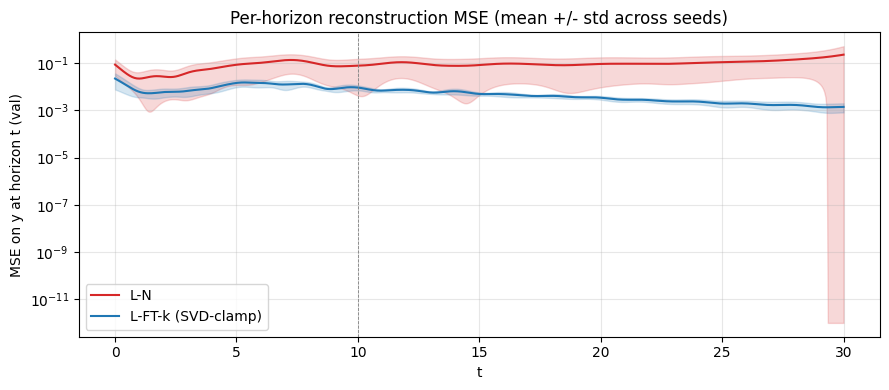

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
for name in MODEL_NAMES:
    yh = ROLL[name]['yhat']; mse_t = np.nanmean((yh - Yva_np[None]) ** 2, axis=1)
    mean = np.nanmean(mse_t, axis=0); std = np.nanstd(mse_t, axis=0); c = MODEL_COLOR[name]
    ax.semilogy(tline_e, np.maximum(mean, 1e-12), color=c, lw=1.5, label=name)
    ax.fill_between(tline_e, np.maximum(mean - std, 1e-12), mean + std, color=c, alpha=0.18)
ax.axvline(T_train, color='gray', lw=0.6, ls='--'); ax.set_xlabel('t'); ax.set_ylabel('MSE on y at horizon t (val)')
ax.set_title('Per-horizon reconstruction MSE (mean +/- std across seeds)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### D5. Implicit recovery of the hidden coordinate $\dot q$
Linear map from latent state to $q$ (observed) and $\dot q$ (hidden), fit/eval split.

Linear recoverability (mean +/- std across seeds; unbounded res=0.01 ref R2->q_dot ~ 0.65):
  L-N                   R2->q 0.912 +/- 0.074   R2->q_dot 0.343 +/- 0.272
  L-FT-k (SVD-clamp)    R2->q 0.994 +/- 0.001   R2->q_dot 0.751 +/- 0.060


/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_2652/2869600439.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(d, labels=MODEL_NAMES, showfliers=False, widths=0.5)
/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_2652/2869600439.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(d, labels=MODEL_NAMES, showfliers=False, widths=0.5)


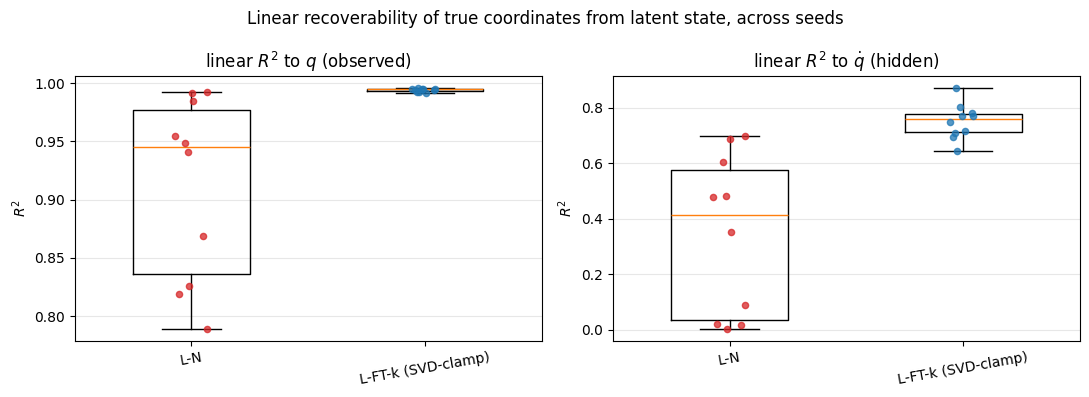

In [20]:
Q    = Xva[..., 0].numpy().reshape(-1); Qdot = Xva[..., 1].numpy().reshape(-1)
perm = np.random.default_rng(7).permutation(Q.shape[0]); half = len(perm)//2
fit_i, ev_i = perm[:half], perm[half:]
def r2_eval(Z, t):
    Zf = np.concatenate([Z[fit_i], np.ones((len(fit_i), 1))], 1)
    w, *_ = np.linalg.lstsq(Zf, t[fit_i], rcond=None)
    pe = np.concatenate([Z[ev_i], np.ones((len(ev_i), 1))], 1) @ w
    return 1 - ((t[ev_i]-pe)**2).sum() / (((t[ev_i]-t[ev_i].mean())**2).sum() + 1e-12)

R2 = {name: {'q': [], 'qdot': []} for name in MODEL_NAMES}
for name in MODEL_NAMES:
    for si in range(len(SEEDS)):
        Z = ROLL[name]['z'][si].reshape(-1, M_LAT).numpy()
        if not np.all(np.isfinite(Z)): R2[name]['q'].append(np.nan); R2[name]['qdot'].append(np.nan); continue
        R2[name]['q'].append(r2_eval(Z, Q)); R2[name]['qdot'].append(r2_eval(Z, Qdot))
print('Linear recoverability (mean +/- std across seeds; unbounded res=0.01 ref R2->q_dot ~ 0.65):')
for name in MODEL_NAMES:
    q = np.array(R2[name]['q']); qd = np.array(R2[name]['qdot'])
    print(f'  {name:20s}  R2->q {np.nanmean(q):.3f} +/- {np.nanstd(q):.3f}   '
          f'R2->q_dot {np.nanmean(qd):.3f} +/- {np.nanstd(qd):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, ttl in [(axes[0], 'q', r'linear $R^2$ to $q$ (observed)'),
                     (axes[1], 'qdot', r'linear $R^2$ to $\dot q$ (hidden)')]:
    d = [np.array(R2[name][key], float) for name in MODEL_NAMES]; d = [x[np.isfinite(x)] for x in d]
    ax.boxplot(d, labels=MODEL_NAMES, showfliers=False, widths=0.5)
    rng = np.random.default_rng(1)
    for i, (name, x) in enumerate(zip(MODEL_NAMES, d), start=1):
        ax.scatter(i + (rng.random(len(x)) - 0.5) * 0.15, x, s=20, color=MODEL_COLOR[name], alpha=0.75, zorder=3)
    ax.set_title(ttl); ax.set_ylabel(r'$R^2$'); ax.grid(alpha=0.3, axis='y'); ax.tick_params(axis='x', rotation=10)
fig.suptitle('Linear recoverability of true coordinates from latent state, across seeds')
plt.tight_layout(); plt.show()

### D6. True Duffing phase portrait

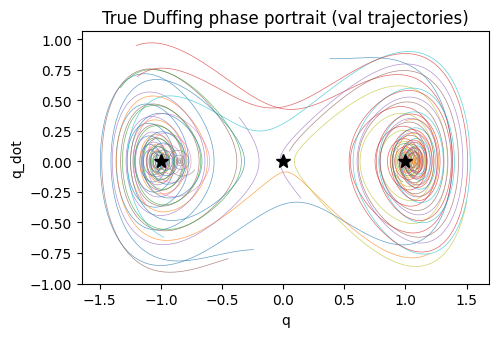

In [21]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(min(16, Xva.shape[0])):
    ax.plot(Xva[i, :, 0].numpy(), Xva[i, :, 1].numpy(), lw=0.5, alpha=0.7)
for xe in equilibria(0.0): ax.plot(xe[0], xe[1], 'k*', ms=10)
ax.set_xlabel('q'); ax.set_ylabel('q_dot'); ax.set_aspect('equal')
ax.set_title('True Duffing phase portrait (val trajectories)'); plt.tight_layout(); plt.show()

### D7. Latent-space geometry (PC1 vs PC2 across seeds)

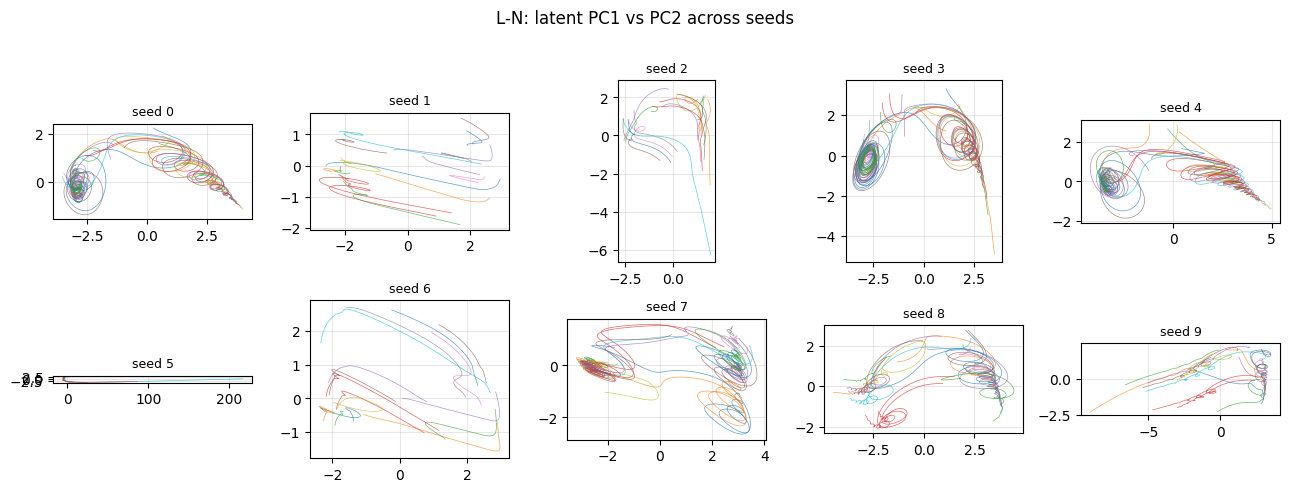

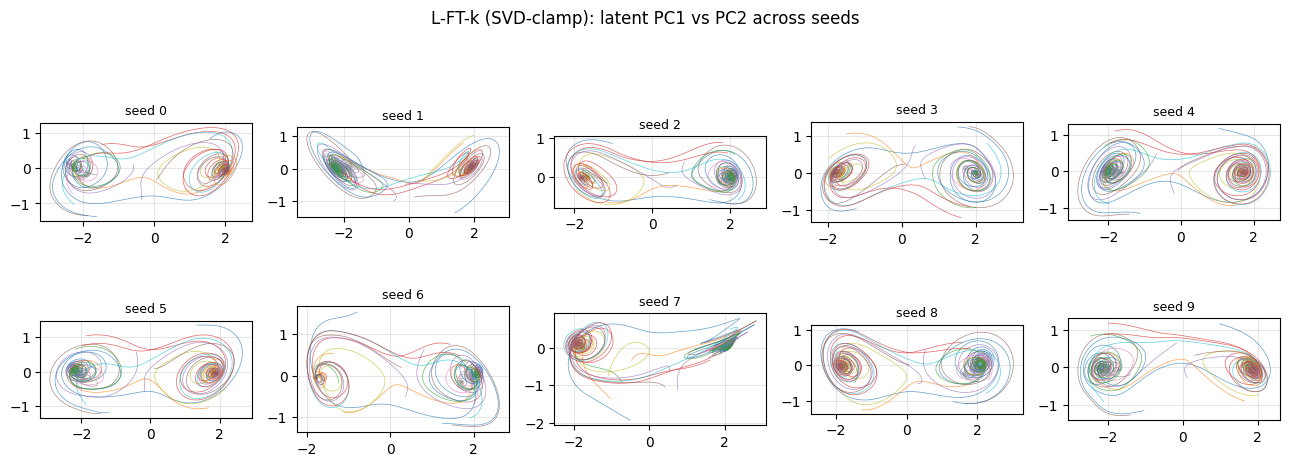

In [ ]:
def pca_2d(Z):
    Zc = Z - Z.mean(axis=0, keepdims=True); U, S, Vt = np.linalg.svd(Zc, full_matrices=False)
    return Zc @ Vt[:2].T, Vt[:2]
for name in MODEL_NAMES:
    fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(2.6, 2.4))
    for si, seed in enumerate(SEEDS):
        ax = axes[si]; Z = ROLL[name]['z'][si].numpy(); Zf = Z.reshape(-1, Z.shape[-1])
        if not np.all(np.isfinite(Zf)):
            ax.set_title(f'seed {seed}: diverged', fontsize=8); ax.set_aspect('equal'); continue
        proj, _ = pca_2d(Zf); proj = proj.reshape(Z.shape[0], Z.shape[1], 2)
        for i in range(min(16, Z.shape[0])): ax.plot(proj[i, :, 0], proj[i, :, 1], lw=0.5, alpha=0.7)
        ax.set_title(f'seed {seed}', fontsize=9); ax.set_aspect('equal'); ax.grid(alpha=0.3)
    fig.suptitle(f'{name}: latent PC1 vs PC2 across seeds', y=1.01); plt.tight_layout(); plt.show()

## Split-term diagnostics
The structured field factorises as $F_\theta(z,u)=A_\theta(z)(z-g_\theta(z,u))$. All three variants
are split (FT) models, so both the $A$-spectrum and the equilibrium-map checks apply to each.

In [23]:
from torch.func import vmap, jacrev
dyn0 = models[FT_NAMES[0]][0].dynamics
sigma_min = float(dyn0.sigma_min); R_g = float(dyn0.R_g)
n_box = 4000
g_t = torch.Generator(device='cpu').manual_seed(0)
Z_box = ((2 * torch.rand(n_box, M_LAT, generator=g_t) - 1) * R_LATENT).to(device)
U_box = ((2 * torch.rand(n_box, generator=g_t) - 1) * u_range).to(device)
u_grid = np.linspace(-u_range, u_range, 200)
branches = np.array([[e[0] for e in equilibria(u)] for u in u_grid])   # (200, 3): sinks + saddle

@torch.no_grad()
def eigvals_A(dyn, Z, chunk=2048):
    if Z.shape[0] == 0: return np.zeros((0, M_LAT), dtype=complex)
    out = [torch.linalg.eigvals(dyn.A(Z[i:i+chunk])).cpu() for i in range(0, Z.shape[0], chunk)]
    return torch.cat(out, 0).numpy()

@torch.no_grad()
def g_image(dyn, Z, U): return dyn.g(Z, U)

def roll_latents(name, si):
    Zfull = ROLL[name]['z'][si]; B, T = Zfull.shape[0], Zfull.shape[1]
    Z = Zfull.reshape(-1, M_LAT); U = Uva_d.detach().cpu().view(-1, 1).expand(B, T).reshape(-1)
    mask = torch.isfinite(Z).all(dim=1)
    return Z[mask].to(device), U[mask].to(device)
def eig_field_jac(dyn, Z, U, chunk=1024):
    '''Eigenvalues of the field Jacobian dF/dz for an unstructured field (e.g. L-N), batched over rows.'''
    def f_single(zi, ui): return dyn.F(zi.unsqueeze(0), ui.unsqueeze(0)).squeeze(0)
    out = []
    for i in range(0, Z.shape[0], chunk):
        J = vmap(jacrev(f_single, argnums=0))(Z[i:i+chunk], U[i:i+chunk])
        out.append(torch.linalg.eigvals(J.detach()).cpu().numpy())
    return np.concatenate(out, 0) if out else np.zeros((0, M_LAT), dtype=complex)

print('split-term analysis for:', FT_NAMES, f'| sigma_min={sigma_min}, R_g={R_g}, c_K={c_K:.3f}')

split-term analysis for: ['L-FT-k (SVD-clamp)'] | sigma_min=0.1, R_g=2.0, c_K=1.440


### D8. Spectrum in the complex plane — $A(z)$ (SVD-clamp) and $\partial F/\partial z$ (L-N)
For the SVD-clamp: eigenvalues of the drift operator $A(z)$; contraction $\mathrm{Re}\,\lambda\le-\sigma_{\min}$
(dashed) and bounded skew $|\mathrm{Im}\,\lambda|\le c_K$ (dotted, Bendixson). For L-N (no split
structure): the field-Jacobian eigenvalues $\mathrm{eig}(\partial F/\partial z)$ over the box, with the
$-\sigma_{\min}$ line shown as a **reference only** (L-N carries no contraction certificate).

Contraction / field-spectrum check  (reference: -sigma_min = -0.100):
  L-N                  [dF/dz]: max Re over seeds = +0.9351  (reference only)
  L-FT-k (SVD-clamp)   [A(z) ]: max Re over seeds = -0.1012  (all <= -sigma_min? True)


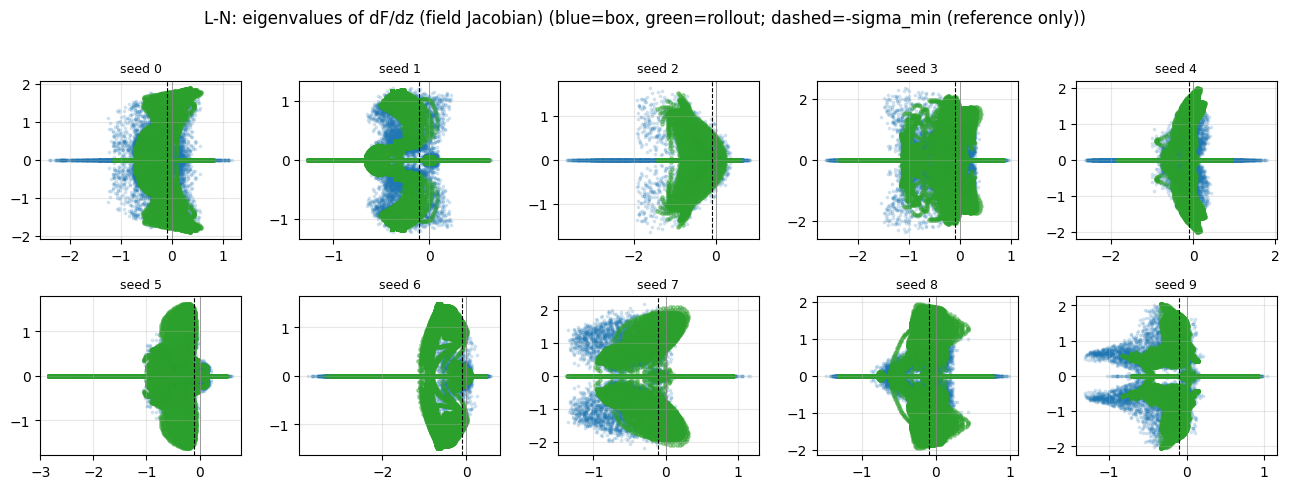

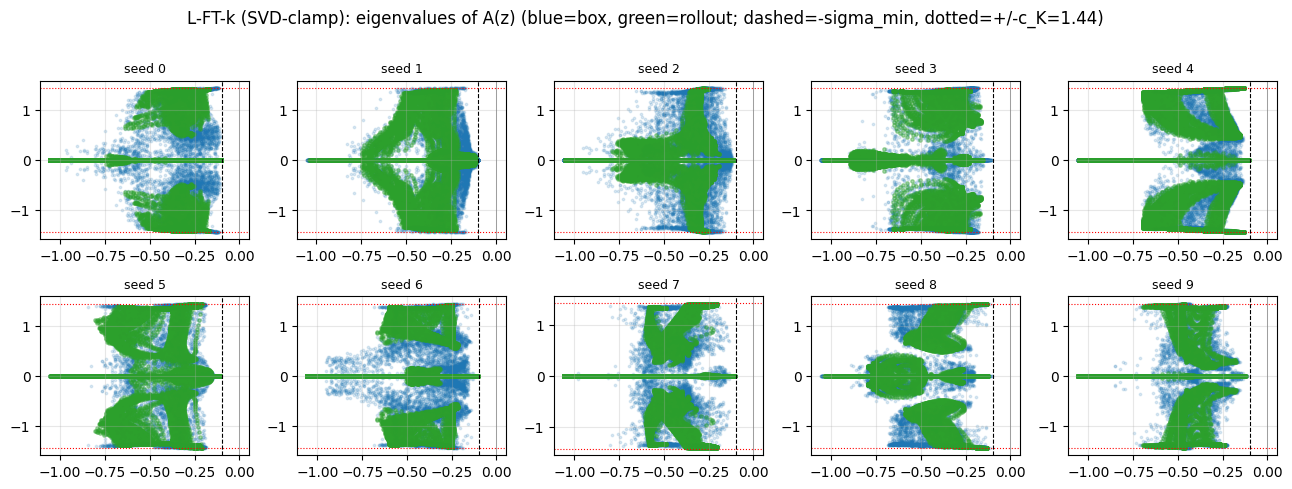

In [24]:
print(f'Contraction / field-spectrum check  (reference: -sigma_min = {-sigma_min:+.3f}):')
for name in MODEL_NAMES:
    use_A = hasattr(models[name][0].dynamics, 'A')
    mr = []
    for si in range(len(SEEDS)):
        Zr, Ur = roll_latents(name, si)
        if Zr.shape[0] == 0: continue
        ev = eigvals_A(models[name][si].dynamics, Zr) if use_A else eig_field_jac(models[name][si].dynamics, Zr, Ur)
        mr.append(ev.real.max())
    mr = np.array(mr) if mr else np.array([np.nan])
    tag = 'A(z)' if use_A else 'dF/dz'
    note = f'(all <= -sigma_min? {bool((mr <= -sigma_min + 1e-4).all())})' if use_A else '(reference only)'
    print(f'  {name:20s} [{tag:5s}]: max Re over seeds = {np.nanmax(mr):+.4f}  {note}')

for name in MODEL_NAMES:
    use_A = hasattr(models[name][0].dynamics, 'A')
    fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(2.6, 2.4))
    for si, seed in enumerate(SEEDS):
        ax = axes[si]; dyn = models[name][si].dynamics
        Zr, Ur = roll_latents(name, si)
        if use_A:
            evb = eigvals_A(dyn, Z_box); evr = eigvals_A(dyn, Zr)
        else:
            evb = eig_field_jac(dyn, Z_box, U_box); evr = eig_field_jac(dyn, Zr, Ur)
        ax.scatter(evb.real.ravel(), evb.imag.ravel(), s=3, alpha=0.15, color='C0')
        if evr.shape[0]: ax.scatter(evr.real.ravel(), evr.imag.ravel(), s=6, alpha=0.4, color='C2')
        ax.axvline(-sigma_min, color='k', ls='--', lw=0.8); ax.axvline(0.0, color='gray', lw=0.5)
        if use_A:
            ax.axhline(c_K, color='r', ls=':', lw=0.8); ax.axhline(-c_K, color='r', ls=':', lw=0.8)
        ax.set_title(f'seed {seed}', fontsize=9); ax.grid(alpha=0.3)
    lbl = 'eigenvalues of A(z)' if use_A else 'eigenvalues of dF/dz (field Jacobian)'
    extra = f', dotted=+/-c_K={c_K:.2f}' if use_A else ' (reference only)'
    fig.suptitle(f'{name}: {lbl} (blue=box, green=rollout; dashed=-sigma_min{extra})', y=1.01)
    plt.tight_layout(); plt.show()

### D9. Decoded equilibrium map $\psi(g(z,u))$ vs true Duffing equilibria
$g$ is unchanged across variants ($R_g\tanh$MLP); this checks the learned equilibrium branch against
the true sinks (solid) and saddle (dashed).

Equilibrium-map bound check  max |g|_inf <= R_g = 2.00:
  L-FT-k (SVD-clamp)  : max |g|_inf over seeds = 2.000  (all <= R_g? True)


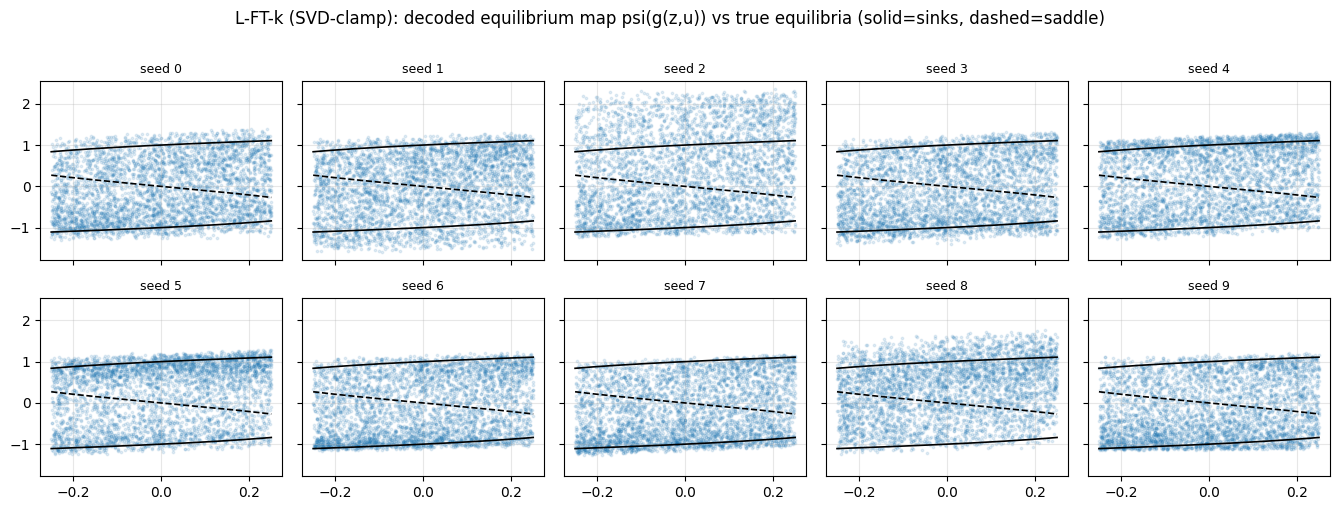

In [25]:
print(f'Equilibrium-map bound check  max |g|_inf <= R_g = {R_g:.2f}:')
for name in FT_NAMES:
    mx = [np.abs(g_image(models[name][si].dynamics, Z_box, U_box).cpu().numpy()).max() for si in range(len(SEEDS))]
    mx = np.array(mx); print(f'  {name:20s}: max |g|_inf over seeds = {mx.max():.3f}  (all <= R_g? {bool((mx <= R_g + 1e-4).all())})')

U_box_np = U_box.cpu().numpy()
for name in FT_NAMES:
    fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(2.7, 2.5), sharex=True, sharey=True)
    for si, seed in enumerate(SEEDS):
        ax = axes[si]
        Gb = g_image(models[name][si].dynamics, Z_box, U_box)
        qg = models[name][si].decode(Gb).detach().cpu().numpy()
        ax.scatter(U_box_np, qg, s=3, alpha=0.12, color='C0')
        ax.plot(u_grid, branches[:, 0], 'k-', lw=1.2); ax.plot(u_grid, branches[:, 2], 'k-', lw=1.2)
        ax.plot(u_grid, branches[:, 1], 'k--', lw=1.2)
        ax.set_title(f'seed {seed}', fontsize=9); ax.grid(alpha=0.3)
    fig.suptitle(f'{name}: decoded equilibrium map psi(g(z,u)) vs true equilibria (solid=sinks, dashed=saddle)', y=1.01)
    plt.tight_layout(); plt.show()